In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, numpy as np, tensorflow as tf, random
if not os.path.exists('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/CIFAR_Assignment', exist_ok=True)
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
from tensorflow.keras.datasets import cifar10
(xtr,ytr),(xte,yte)=cifar10.load_data()
X=np.concatenate([xtr,xte],axis=0).astype('float32')/255.0
y=np.concatenate([ytr,yte],axis=0)
idx=np.random.RandomState(SEED).permutation(len(X))
split=int(0.8*len(X))
X_train,X_test=X[idx[:split]],X[idx[split:]]
y_train,y_test=y[idx[:split]],y[idx[split:]]
np.save('/content/drive/MyDrive/CIFAR_Assignment/X_train.npy',X_train)
np.save('/content/drive/MyDrive/CIFAR_Assignment/X_test.npy',X_test)
np.save('/content/drive/MyDrive/CIFAR_Assignment/y_train.npy',y_train)
np.save('/content/drive/MyDrive/CIFAR_Assignment/y_test.npy',y_test)
print('tf',tf.__version__,'gpu',tf.config.list_physical_devices('GPU'))
print('X_train',X_train.shape,'X_test',X_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
tf 2.19.0 gpu []
X_train (48000, 32, 32, 3) X_test (12000, 32, 32, 3)


In [ ]:
import os, numpy as np, tensorflow as tf, json
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau
base_dir = '/content/drive/MyDrive/CIFAR_Assignment'
X_train = np.load(base_dir + '/X_train.npy')
X_test = np.load(base_dir + '/X_test.npy')
y_train = np.load(base_dir + '/y_train.npy')
y_test = np.load(base_dir + '/y_test.npy')
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
model = Sequential([
    InputLayer(input_shape=(32,32,3)),
    Conv2D(32,3,padding='same',activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(64,3,padding='same',activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),
    Conv2D(128,3,padding='same',activation='relu'),
    BatchNormalization(),
    GlobalAveragePooling2D(),
    Dense(128,activation='relu'),
    Dropout(0.4),
    Dense(10,activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
os.makedirs(base_dir + '/checkpoints', exist_ok=True)
ckpt = ModelCheckpoint(base_dir + '/checkpoints/cnn_best.h5', monitor='val_accuracy', save_best_only=True, mode='max')
csv = CSVLogger(base_dir + '/cnn_history.csv', append=False)
es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
callbacks = [ckpt, csv, es, rlr]
print(model.summary())
history = model.fit(X_train, y_train_cat, epochs=12, batch_size=64, validation_split=0.1, callbacks=callbacks, verbose=1)
with open(base_dir + '/cnn_history.json','w') as f:
    json.dump(history.history, f)
res = model.evaluate(X_test, y_test_cat, batch_size=64, verbose=1)
print('test_loss',res[0],'test_acc',res[1])
print('saved:', base_dir + '/checkpoints/cnn_best.h5', base_dir + '/cnn_history.csv', base_dir + '/cnn_history.json')


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

...

675/675 ━━━━━━━━━━━━━━━━━━━━ 141s 209ms/step - accuracy: 0.7492 - loss: 0.7232 - val_accuracy: 0.6377 - val_loss: 1.0670 - learning_rate: 0.0010
Epoch 6/12
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.7765 - loss: 0.6508

675/675 ━━━━━━━━━━━━━━━━━━━━ 140s 208ms/step - accuracy: 0.7765 - loss: 0.6508 - val_accuracy: 0.6448 - val_loss: 1.0357 - learning_rate: 0.0010
Epoch 7/12
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 210ms/step - accuracy: 0.7962 - loss: 0.5886 - val_accuracy: 0.6329 - val_loss: 1.1228 - learning_rate: 0.0010
Epoch 8/12
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8101 - loss: 0.5468

675/675 ━━━━━━━━━━━━━━━━━━━━ 139s 205ms/step - accuracy: 0.8101 - loss: 0.5467 - val_accuracy: 0.6617 - val_loss: 1.0376 - learning_rate: 0.0010
Epoch 9/12
675/675 ━━━━━━━━━━━━━━━━━━━━ 145s 210ms/step - accuracy: 0.8272 - loss: 0.5008 - val_accuracy: 0.6398 - val_loss: 1.1661 - learning_rate: 0.0010
Epoch 10/12
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8576 - loss: 0.4198

675/675 ━━━━━━━━━━━━━━━━━━━━ 140s 208ms/step - accuracy: 0.8577 - loss: 0.4198 - val_accuracy: 0.6975 - val_loss: 0.9728 - learning_rate: 5.0000e-04
Epoch 11/12
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 207ms/step - accuracy: 0.8753 - loss: 0.3607 - val_accuracy: 0.6917 - val_loss: 1.0105 - learning_rate: 5.0000e-04
Epoch 12/12
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.8886 - loss: 0.3265

675/675 ━━━━━━━━━━━━━━━━━━━━ 140s 207ms/step - accuracy: 0.8886 - loss: 0.3265 - val_accuracy: 0.7069 - val_loss: 0.9743 - learning_rate: 5.0000e-04
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.6971 - loss: 0.9601
test_loss 0.9693734645843506 test_acc 0.6992499828338623
saved: /content/drive/MyDrive/CIFAR_Assignment/checkpoints/cnn_best.h5 /content/drive/MyDrive/CIFAR_Assignment/cnn_history.csv /content/drive/MyDrive/CIFAR_Assignment/cnn_history.json


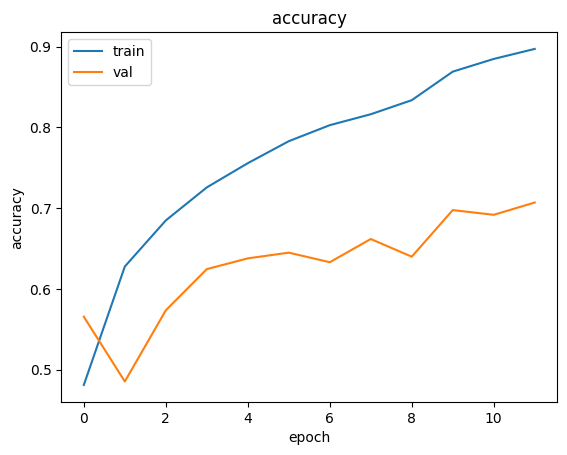

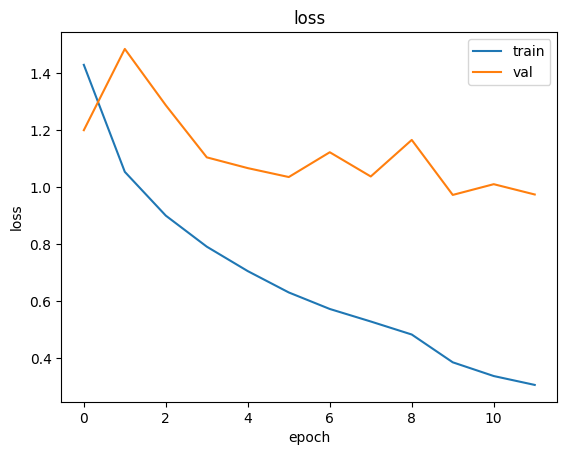

188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.7072 - loss: 0.9649
test_loss 0.9728600978851318 test_acc 0.7107499837875366
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step


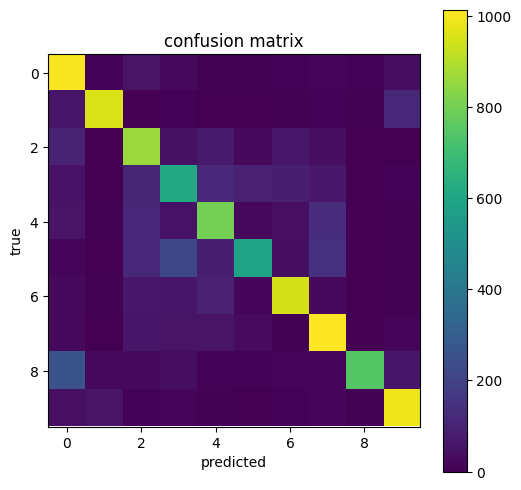

              precision    recall  f1-score   support

    airplane     0.6151    0.8539    0.7150      1177
  automobile     0.9053    0.8192    0.8601      1167
        bird     0.6082    0.7115    0.6558      1213
         cat     0.5431    0.5328    0.5379      1158
        deer     0.6442    0.6579    0.6510      1219
         dog     0.7487    0.4827    0.5870      1216
        frog     0.7758    0.7608    0.7682      1246
       horse     0.6884    0.8054    0.7423      1259
        ship     0.9565    0.6249    0.7559      1197
       truck     0.7918    0.8615    0.8252      1148

    accuracy                         0.7107     12000
   macro avg     0.7277    0.7111    0.7099     12000
weighted avg     0.7275    0.7107    0.7096     12000

Saved: /content/drive/MyDrive/CIFAR_Assignment/figures/accuracy.png /content/drive/MyDrive/CIFAR_Assignment/figures/loss.png /content/drive/MyDrive/CIFAR_Assignment/figures/confusion_matrix.png /content/drive/MyDrive/CIFAR_Assignment/figures

In [ ]:
import os, json, numpy as np, tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
base_dir = '/content/drive/MyDrive/CIFAR_Assignment'
with open(base_dir + '/cnn_history.json','r') as f:
    h = json.load(f)
acc = h.get('accuracy', h.get('acc', []))
val_acc = h.get('val_accuracy', h.get('val_acc', []))
loss = h.get('loss', [])
val_loss = h.get('val_loss', [])
os.makedirs(base_dir + '/figures', exist_ok=True)
plt.figure()
plt.plot(acc); plt.plot(val_acc); plt.title('accuracy'); plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(['train','val'])
plt.savefig(base_dir + '/figures/accuracy.png', bbox_inches='tight'); plt.show()
plt.figure()
plt.plot(loss); plt.plot(val_loss); plt.title('loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(['train','val'])
plt.savefig(base_dir + '/figures/loss.png', bbox_inches='tight'); plt.show()
X_test = np.load(base_dir + '/X_test.npy')
y_test = np.load(base_dir + '/y_test.npy').ravel()
model_path = base_dir + '/checkpoints/cnn_best.h5'
try:
    model = tf.keras.models.load_model(model_path)
except Exception:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import InputLayer, Conv2D, BatchNormalization, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
    model = Sequential([
        InputLayer(input_shape=(32,32,3)),
        Conv2D(32,3,padding='same',activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),
        Conv2D(64,3,padding='same',activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),
        Conv2D(128,3,padding='same',activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling2D(),
        Dense(128,activation='relu'),
        Dropout(0.4),
        Dense(10,activation='softmax')
    ])
    model.load_weights(model_path)
res = model.evaluate(X_test, tf.keras.utils.to_categorical(y_test,10), batch_size=64, verbose=1)
print('test_loss',res[0],'test_acc',res[1])
preds = model.predict(X_test, batch_size=128, verbose=1)
y_pred = preds.argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest'); plt.title('confusion matrix'); plt.colorbar(); plt.xlabel('predicted'); plt.ylabel('true')
plt.savefig(base_dir + '/figures/confusion_matrix.png', bbox_inches='tight'); plt.show()
labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
cr = classification_report(y_test, y_pred, target_names=labels, digits=4)
print(cr)
with open(base_dir + '/figures/classification_report.txt','w') as f:
    f.write(cr)
print('Saved:', base_dir + '/figures/accuracy.png', base_dir + '/figures/loss.png', base_dir + '/figures/confusion_matrix.png', base_dir + '/figures/classification_report.txt')


In [ ]:
import os, json, numpy as np, tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
base_dir='/content/drive/MyDrive/CIFAR_Assignment'
X=np.load(base_dir+'/X_train.npy')
y=np.load(base_dir+'/y_train.npy').ravel()
X_test=np.load(base_dir+'/X_test.npy')
y_test=np.load(base_dir+'/y_test.npy').ravel()
val_size=int(0.1*len(X))
X_tr, X_val = X[:-val_size], X[-val_size:]
y_tr, y_val = y[:-val_size], y[-val_size:]
AUTOTUNE=tf.data.AUTOTUNE
IMAGE_SIZE=96
BATCH=128
EPOCHS=6
def make_ds(a,b,shuffle=False):
    ds=tf.data.Dataset.from_tensor_slices((a,b))
    ds=ds.map(lambda u,v:(tf.image.resize(u,[IMAGE_SIZE,IMAGE_SIZE]), tf.one_hot(v,10)), num_parallel_calls=AUTOTUNE)
    ds=ds.map(lambda u,v:(preprocess_input(u*255.0), v), num_parallel_calls=AUTOTUNE)
    if shuffle: ds=ds.shuffle(8192,seed=42)
    ds=ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds
train_ds=make_ds(X_tr,y_tr,shuffle=True)
val_ds=make_ds(X_val,y_val,shuffle=False)
test_ds=make_ds(X_test,y_test,shuffle=False)
inp=Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))
base=MobileNetV2(include_top=False, weights='imagenet', input_tensor=inp)
base.trainable=False
x=GlobalAveragePooling2D()(base.output)
x=Dense(256,activation='relu')(x)
x=Dropout(0.3)(x)
out=Dense(10,activation='softmax')(x)
model=Model(inputs=base.input,outputs=out)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
os.makedirs(base_dir+'/checkpoints',exist_ok=True)
ckpt=ModelCheckpoint(base_dir+'/checkpoints/mobilenetv2_best.h5',monitor='val_accuracy',save_best_only=True,mode='max')
csv=CSVLogger(base_dir+'/mobilenetv2_history.csv',append=False)
es=EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True)
rlr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=2)
callbacks=[ckpt,csv,es,rlr]
print(model.summary())
history=model.fit(train_ds,epochs=EPOCHS,validation_data=val_ds,callbacks=callbacks,verbose=1)
with open(base_dir+'/mobilenetv2_history.json','w') as f: json.dump(history.history,f)
res=model.evaluate(test_ds,verbose=1)
print('test_loss',res[0],'test_acc',res[1])
print('saved:', base_dir+'/checkpoints/mobilenetv2_best.h5', base_dir+'/mobilenetv2_history.csv', base_dir+'/mobilenetv2_history.json')


/tmp/ipython-input-1493994782.py:29: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base=MobileNetV2(include_top=False, weights='imagenet', input_tensor=inp)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

...

338/338 ━━━━━━━━━━━━━━━━━━━━ 479s 1s/step - accuracy: 0.7093 - loss: 0.8580 - val_accuracy: 0.7735 - val_loss: 0.6738 - learning_rate: 1.0000e-04
Epoch 3/6
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7475 - loss: 0.7319

338/338 ━━━━━━━━━━━━━━━━━━━━ 415s 1s/step - accuracy: 0.7475 - loss: 0.7319 - val_accuracy: 0.7894 - val_loss: 0.6351 - learning_rate: 1.0000e-04
Epoch 4/6
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7730 - loss: 0.6709

338/338 ━━━━━━━━━━━━━━━━━━━━ 412s 1s/step - accuracy: 0.7730 - loss: 0.6709 - val_accuracy: 0.7977 - val_loss: 0.6054 - learning_rate: 1.0000e-04
Epoch 5/6
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7858 - loss: 0.6249

338/338 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.7858 - loss: 0.6249 - val_accuracy: 0.8023 - val_loss: 0.5841 - learning_rate: 1.0000e-04
Epoch 6/6
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7977 - loss: 0.5933

338/338 ━━━━━━━━━━━━━━━━━━━━ 414s 1s/step - accuracy: 0.7977 - loss: 0.5933 - val_accuracy: 0.8081 - val_loss: 0.5722 - learning_rate: 1.0000e-04
94/94 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8002 - loss: 0.5930
test_loss 0.5896312594413757 test_acc 0.7992500066757202
saved: /content/drive/MyDrive/CIFAR_Assignment/checkpoints/mobilenetv2_best.h5 /content/drive/MyDrive/CIFAR_Assignment/mobilenetv2_history.csv /content/drive/MyDrive/CIFAR_Assignment/mobilenetv2_history.json


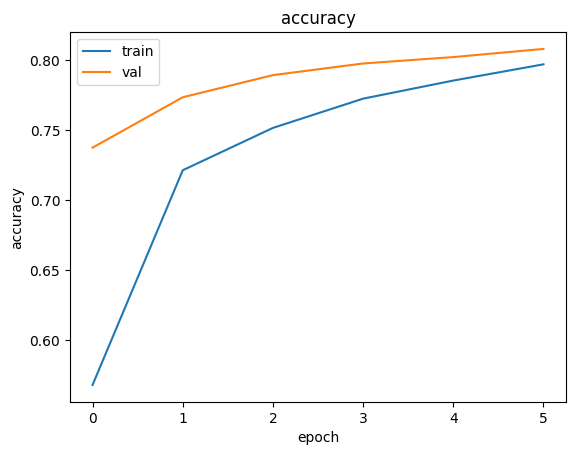

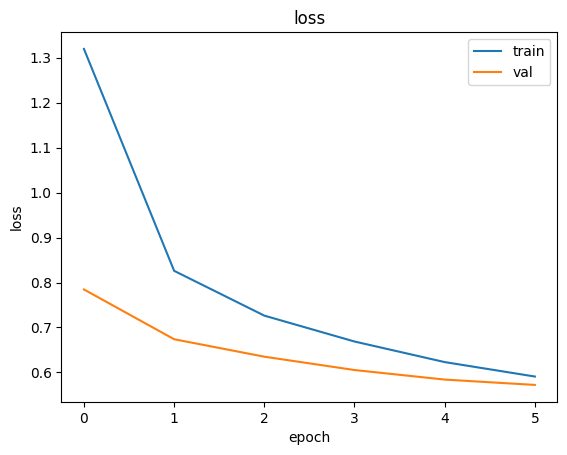

test_loss 0.5896314978599548 test_acc 0.7992500066757202


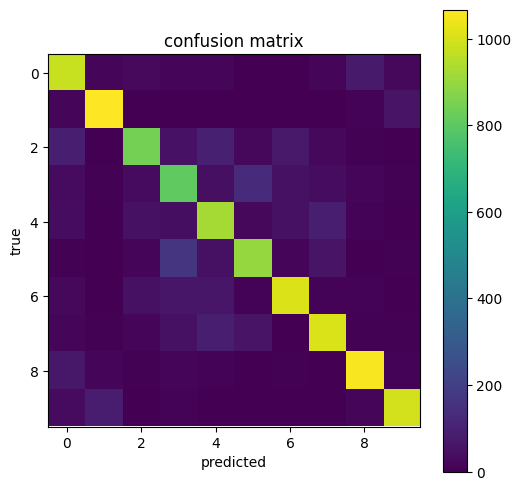

              precision    recall  f1-score   support

    airplane     0.7544    0.8301    0.7905      1177
  automobile     0.8783    0.9152    0.8963      1167
        bird     0.8063    0.6966    0.7475      1213
         cat     0.6615    0.6986    0.6795      1158
        deer     0.7161    0.7572    0.7360      1219
         dog     0.7870    0.7385    0.7620      1216
        frog     0.8348    0.8114    0.8230      1246
       horse     0.8103    0.8006    0.8054      1259
        ship     0.8680    0.8847    0.8763      1197
       truck     0.8922    0.8650    0.8784      1148

    accuracy                         0.7993     12000
   macro avg     0.8009    0.7998    0.7995     12000
weighted avg     0.8009    0.7993    0.7992     12000



Saved: /content/drive/MyDrive/CIFAR_Assignment/figures/mnv2_accuracy.png /content/drive/MyDrive/CIFAR_Assignment/figures/mnv2_loss.png /content/drive/MyDrive/CIFAR_Assignment/figures/mnv2_confusion_matrix.png /content/drive/MyDrive/CIFAR_Assignment/figures/mnv2_classification_report.txt /content/drive/MyDrive/CIFAR_Assignment/mobilenetv2_summary.txt


In [ ]:
import os, json, numpy as np, tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
base_dir='/content/drive/MyDrive/CIFAR_Assignment'
with open(base_dir+'/mobilenetv2_history.json','r') as f: h=json.load(f)
acc=h.get('accuracy',[])
val_acc=h.get('val_accuracy',[])
loss=h.get('loss',[])
val_loss=h.get('val_loss',[])
os.makedirs(base_dir+'/figures',exist_ok=True)
plt.figure(); plt.plot(acc); plt.plot(val_acc); plt.title('accuracy'); plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(['train','val']); plt.savefig(base_dir+'/figures/mnv2_accuracy.png',bbox_inches='tight'); plt.show()
plt.figure(); plt.plot(loss); plt.plot(val_loss); plt.title('loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(['train','val']); plt.savefig(base_dir+'/figures/mnv2_loss.png',bbox_inches='tight'); plt.show()
X_test=np.load(base_dir+'/X_test.npy')
y_test=np.load(base_dir+'/y_test.npy').ravel()
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
Xr=tf.image.resize(X_test,[96,96])
Xp=preprocess_input(Xr*255.0)
model=tf.keras.models.load_model(base_dir+'/checkpoints/mobilenetv2_best.h5')
res=model.evaluate(Xp,tf.keras.utils.to_categorical(y_test,10),verbose=0)
print('test_loss',res[0],'test_acc',res[1])
pred=model.predict(Xp,verbose=0)
y_pred=pred.argmax(axis=1)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,6)); plt.imshow(cm,interpolation='nearest'); plt.title('confusion matrix'); plt.colorbar(); plt.xlabel('predicted'); plt.ylabel('true'); plt.savefig(base_dir+'/figures/mnv2_confusion_matrix.png',bbox_inches='tight'); plt.show()
labels=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
cr=classification_report(y_test,y_pred,target_names=labels,digits=4)
print(cr)
with open(base_dir+'/figures/mnv2_classification_report.txt','w') as f: f.write(cr)
with open(base_dir+'/mobilenetv2_summary.txt','w') as f: model.summary(print_fn=lambda x: f.write(x+'\n'))
print('Saved:', base_dir+'/figures/mnv2_accuracy.png', base_dir+'/figures/mnv2_loss.png', base_dir+'/figures/mnv2_confusion_matrix.png', base_dir+'/figures/mnv2_classification_report.txt', base_dir+'/mobilenetv2_summary.txt')


In [ ]:
import os, json, numpy as np, tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input

base_dir='/content/drive/MyDrive/CIFAR_Assignment'
X=np.load(base_dir+'/X_train.npy')
y=np.load(base_dir+'/y_train.npy').ravel()
X_test=np.load(base_dir+'/X_test.npy')
y_test=np.load(base_dir+'/y_test.npy').ravel()

val_size=int(0.1*len(X))
X_tr, X_val = X[:-val_size], X[-val_size:]
y_tr, y_val = y[:-val_size], y[-val_size:]

AUTOTUNE=tf.data.AUTOTUNE
IMAGE_SIZE=96
BATCH=128
EPOCHS=6

def make_ds(a,b,shuffle=False):
    ds=tf.data.Dataset.from_tensor_slices((a,b))
    ds=ds.map(lambda u,v:(tf.image.resize(u,[IMAGE_SIZE,IMAGE_SIZE]), tf.one_hot(v,10)), num_parallel_calls=AUTOTUNE)
    ds=ds.map(lambda u,v:(preprocess_input(u*255.0), v), num_parallel_calls=AUTOTUNE)
    if shuffle: ds=ds.shuffle(8192,seed=42)
    ds=ds.batch(BATCH).prefetch(AUTOTUNE)
    return ds

train_ds=make_ds(X_tr,y_tr,shuffle=True)
val_ds=make_ds(X_val,y_val,shuffle=False)
test_ds=make_ds(X_test,y_test,shuffle=False)

inp=Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))
base=ResNet50V2(include_top=False, weights='imagenet', input_tensor=inp)
base.trainable=False
x=GlobalAveragePooling2D()(base.output)
x=Dense(256,activation='relu')(x)
x=Dropout(0.3)(x)
out=Dense(10,activation='softmax')(x)
model=Model(inputs=base.input,outputs=out)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

os.makedirs(base_dir+'/checkpoints',exist_ok=True)
ckpt=ModelCheckpoint(base_dir+'/checkpoints/resnet50v2_best.h5',monitor='val_accuracy',save_best_only=True,mode='max')
csv=CSVLogger(base_dir+'/resnet50v2_history.csv',append=False)
es=EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True)
rlr=ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=2)
callbacks=[ckpt,csv,es,rlr]

print(model.summary())
history=model.fit(train_ds,epochs=EPOCHS,validation_data=val_ds,callbacks=callbacks,verbose=1)

with open(base_dir+'/resnet50v2_history.json','w') as f: json.dump(history.history,f)
res=model.evaluate(test_ds,verbose=1)
print('test_loss',res[0],'test_acc',res[1])
print('saved:', base_dir+'/checkpoints/resnet50v2_best.h5', base_dir+'/resnet50v2_history.csv', base_dir+'/resnet50v2_history.json')


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 102, 102,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 48, 48,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 50, 50,    │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 24, 24,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 24, 24,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 24, 24,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 24, 24,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 24, 24,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 24, 24,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 26, 26,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 24, 24,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 24, 24,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 24, 24,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 24, 24,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 24, 24,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 24, 24,    │          0 │ conv2_block1_0_c

 Total params: 24,091,914 (91.90 MB)

 Trainable params: 527,114 (2.01 MB)

...

338/338 ━━━━━━━━━━━━━━━━━━━━ 1630s 5s/step - accuracy: 0.7194 - loss: 0.8411 - val_accuracy: 0.7696 - val_loss: 0.6808 - learning_rate: 1.0000e-04
Epoch 3/6
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7600 - loss: 0.7119

338/338 ━━━━━━━━━━━━━━━━━━━━ 1597s 5s/step - accuracy: 0.7600 - loss: 0.7118 - val_accuracy: 0.7827 - val_loss: 0.6396 - learning_rate: 1.0000e-04
Epoch 4/6
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7801 - loss: 0.6343

338/338 ━━━━━━━━━━━━━━━━━━━━ 1560s 5s/step - accuracy: 0.7801 - loss: 0.6343 - val_accuracy: 0.7908 - val_loss: 0.6192 - learning_rate: 1.0000e-04
Epoch 5/6
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8012 - loss: 0.5788

338/338 ━━━━━━━━━━━━━━━━━━━━ 1551s 5s/step - accuracy: 0.8012 - loss: 0.5788 - val_accuracy: 0.7971 - val_loss: 0.6000 - learning_rate: 1.0000e-04
Epoch 6/6
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8128 - loss: 0.5422

338/338 ━━━━━━━━━━━━━━━━━━━━ 1630s 5s/step - accuracy: 0.8128 - loss: 0.5421 - val_accuracy: 0.8006 - val_loss: 0.5863 - learning_rate: 1.0000e-04
94/94 ━━━━━━━━━━━━━━━━━━━━ 388s 4s/step - accuracy: 0.7969 - loss: 0.6076
test_loss 0.6009887456893921 test_acc 0.796500027179718
saved: /content/drive/MyDrive/CIFAR_Assignment/checkpoints/resnet50v2_best.h5 /content/drive/MyDrive/CIFAR_Assignment/resnet50v2_history.csv /content/drive/MyDrive/CIFAR_Assignment/resnet50v2_history.json


Mounted at /content/drive


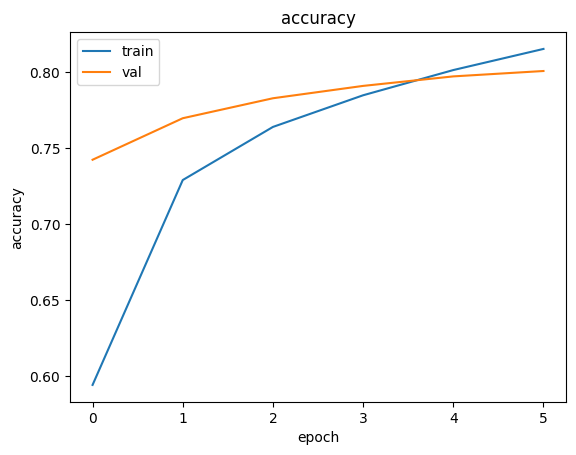

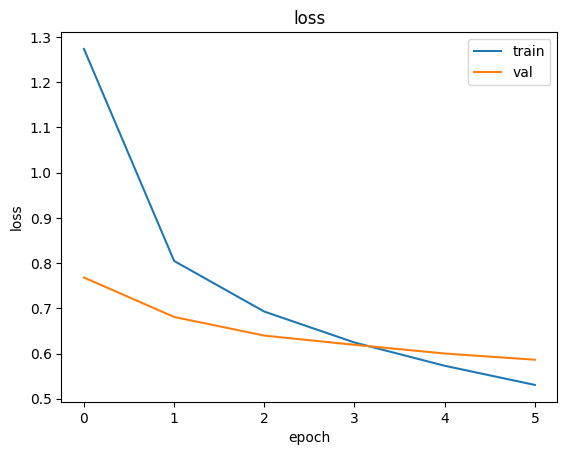

test_loss 0.6009887456893921 test_acc 0.796500027179718


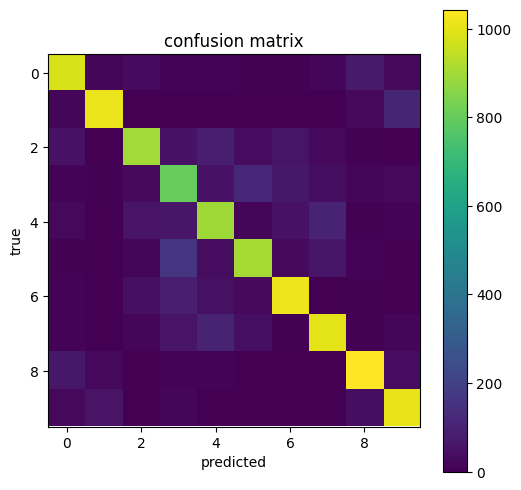

              precision    recall  f1-score   support

    airplane     0.8223    0.8335    0.8278      1177
  automobile     0.9019    0.8663    0.8837      1167
        bird     0.8218    0.7411    0.7794      1213
         cat     0.6393    0.6917    0.6645      1158
        deer     0.7218    0.7342    0.7279      1219
         dog     0.7834    0.7434    0.7629      1216
        frog     0.8215    0.8162    0.8188      1246
       horse     0.8013    0.7943    0.7978      1259
        ship     0.8500    0.8713    0.8606      1197
       truck     0.8174    0.8772    0.8462      1148

    accuracy                         0.7965     12000
   macro avg     0.7981    0.7969    0.7970     12000
weighted avg     0.7982    0.7965    0.7968     12000



Saved: /content/drive/MyDrive/CIFAR_Assignment/figures/resnet_accuracy.png /content/drive/MyDrive/CIFAR_Assignment/figures/resnet_loss.png /content/drive/MyDrive/CIFAR_Assignment/figures/resnet_confusion_matrix.png /content/drive/MyDrive/CIFAR_Assignment/figures/resnet_classification_report.txt /content/drive/MyDrive/CIFAR_Assignment/resnet50v2_summary.txt


In [ ]:
import os, json, numpy as np, tensorflow as tf, pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.resnet_v2 import preprocess_input

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

base_dir = '/content/drive/MyDrive/CIFAR_Assignment'
hist_json = base_dir + '/resnet50v2_history.json'
hist_csv  = base_dir + '/resnet50v2_history.csv'
os.makedirs(base_dir + '/figures', exist_ok=True)

def load_history():
    if os.path.exists(hist_json):
        with open(hist_json, 'r') as f:
            h = json.load(f)
        return h.get('accuracy', []), h.get('val_accuracy', []), h.get('loss', []), h.get('val_loss', [])
    if os.path.exists(hist_csv):
        df = pd.read_csv(hist_csv)
        return df.get('accuracy', pd.Series([])).tolist(), df.get('val_accuracy', pd.Series([])).tolist(), df.get('loss', pd.Series([])).tolist(), df.get('val_loss', pd.Series([])).tolist()
    return [], [], [], []

acc, val_acc, loss, val_loss = load_history()

plt.figure(); plt.plot(acc); plt.plot(val_acc); plt.title('accuracy'); plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(['train','val'])
plt.savefig(base_dir + '/figures/resnet_accuracy.png', bbox_inches='tight'); plt.show()

plt.figure(); plt.plot(loss); plt.plot(val_loss); plt.title('loss'); plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(['train','val'])
plt.savefig(base_dir + '/figures/resnet_loss.png', bbox_inches='tight'); plt.show()

X_test = np.load(base_dir + '/X_test.npy')
y_test = np.load(base_dir + '/y_test.npy').ravel()
Xr = tf.image.resize(X_test, [96,96])
Xp = preprocess_input(Xr*255.0)

model = tf.keras.models.load_model(base_dir + '/checkpoints/resnet50v2_best.h5')
res = model.evaluate(Xp, tf.keras.utils.to_categorical(y_test,10), verbose=0)
print('test_loss', res[0], 'test_acc', res[1])

pred = model.predict(Xp, verbose=0)
y_pred = pred.argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6)); plt.imshow(cm, interpolation='nearest'); plt.title('confusion matrix'); plt.colorbar(); plt.xlabel('predicted'); plt.ylabel('true')
plt.savefig(base_dir + '/figures/resnet_confusion_matrix.png', bbox_inches='tight'); plt.show()

labels = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
cr = classification_report(y_test, y_pred, target_names=labels, digits=4)
print(cr)

with open(base_dir + '/figures/resnet_classification_report.txt','w') as f: f.write(cr)
with open(base_dir + '/resnet50v2_summary.txt','w') as f: model.summary(print_fn=lambda x: f.write(x+'\n'))

print('Saved:', base_dir + '/figures/resnet_accuracy.png', base_dir + '/figures/resnet_loss.png', base_dir + '/figures/resnet_confusion_matrix.png', base_dir + '/figures/resnet_classification_report.txt', base_dir + '/resnet50v2_summary.txt')

